In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_synaptic_density_1 = pd.read_csv('/home/rad216/phd/simple_column_clean/runs/run_20240621_134433_original_parameters_g_15_changeFR_pv5/metrics/avg_firing_rates.csv')
df_synaptic_density_1["Avg Firing Rate Hz"] = pd.to_numeric(df_synaptic_density_1["Avg Firing Rate Hz"])


In [13]:
df_synaptic_density_1

,Population,Avg Firing Rate Hz
0,L1VIP,0.86
1,L23E,0.28
2,L23PV,2.68
3,L23SST,3.55
4,L23VIP,7.91
5,L4E,1.23
6,L4PV,3.79
7,L4SST,1.87
8,L4VIP,0.83
9,L5E,2.06


In [14]:
# df_synaptic_density_1['Color'] = df_synaptic_density_1['Population'].apply(
#     lambda x: 'VIP' if x.endswith('P') else 'E' if x.endswith('E') else 'PV' if x.endswith('V') else 'SST'
# )

# # Define the color palette for the custom labels
# palette = {'VIP': 'yellow', 'E': 'red', 'PV': 'blue', 'SST': 'green'}

# # Plot using seaborn
# sns.barplot(data=df_synaptic_density_1, x='Avg Firing Rate Hz', y='Population', hue='Color', palette=palette, dodge=False)

# # Properly display the legend with the right labels and colors
# plt.legend(title="Type")
# plt.show()

In [15]:
df_synaptic_density_08 = pd.read_csv('/home/rad216/phd/simple_column_clean/runs/run_20240621_135849_new_rates_g15/metrics/avg_firing_rates.csv')
df_synaptic_density_08["Avg Firing Rate Hz"] = pd.to_numeric(df_synaptic_density_08["Avg Firing Rate Hz"])


In [16]:
df_synaptic_density_05 = pd.read_csv('/home/rad216/phd/simple_column_clean/runs/run_20240621_135849_new_rates_g15/metrics/avg_firing_rates.csv')
df_synaptic_density_05["Avg Firing Rate Hz"] = pd.to_numeric(df_synaptic_density_05["Avg Firing Rate Hz"])


In [17]:
df_synaptic_density_0 = pd.read_csv('/home/rad216/phd/simple_column_clean/runs/run_20240621_135849_new_rates_g15/metrics/avg_firing_rates.csv')
df_synaptic_density_0["Avg Firing Rate Hz"] = pd.to_numeric(df_synaptic_density_0["Avg Firing Rate Hz"])


In [18]:
df_synaptic_density_1 = df_synaptic_density_1.rename(columns={"Avg Firing Rate Hz": "Synaptic Density 1 FR"})
df_synaptic_density_08 = df_synaptic_density_08.rename(columns={"Avg Firing Rate Hz": "Synaptic Density 0.8 FR"})
df_synaptic_density_08 = df_synaptic_density_08.drop(['Population'], axis=1)
df_synaptic_density_05 = df_synaptic_density_05.rename(columns={"Avg Firing Rate Hz": "Synaptic Density 0.5 FR"})
df_synaptic_density_05 = df_synaptic_density_05.drop(['Population'], axis=1)
df_synaptic_density_0 = df_synaptic_density_0.rename(columns={"Avg Firing Rate Hz": "Synaptic Density 0 FR"})
df_synaptic_density_0 = df_synaptic_density_0.drop(['Population'], axis=1)



In [19]:
combined_data = pd.concat([df_synaptic_density_1, df_synaptic_density_08, df_synaptic_density_05, df_synaptic_density_0], axis=1, join='outer')

In [20]:
combined_data

,Population,Synaptic Density 1 FR,Synaptic Density 0.8 FR,Synaptic Density 0.5 FR,Synaptic Density 0 FR
0,L1VIP,0.86,1.37,1.37,1.37
1,L23E,0.28,0.37,0.37,0.37
2,L23PV,2.68,2.52,2.52,2.52
3,L23SST,3.55,3.23,3.23,3.23
4,L23VIP,7.91,7.97,7.97,7.97
5,L4E,1.23,1.37,1.37,1.37
6,L4PV,3.79,3.92,3.92,3.92
7,L4SST,1.87,1.92,1.92,1.92
8,L4VIP,0.83,1.63,1.63,1.63
9,L5E,2.06,1.70,1.70,1.70


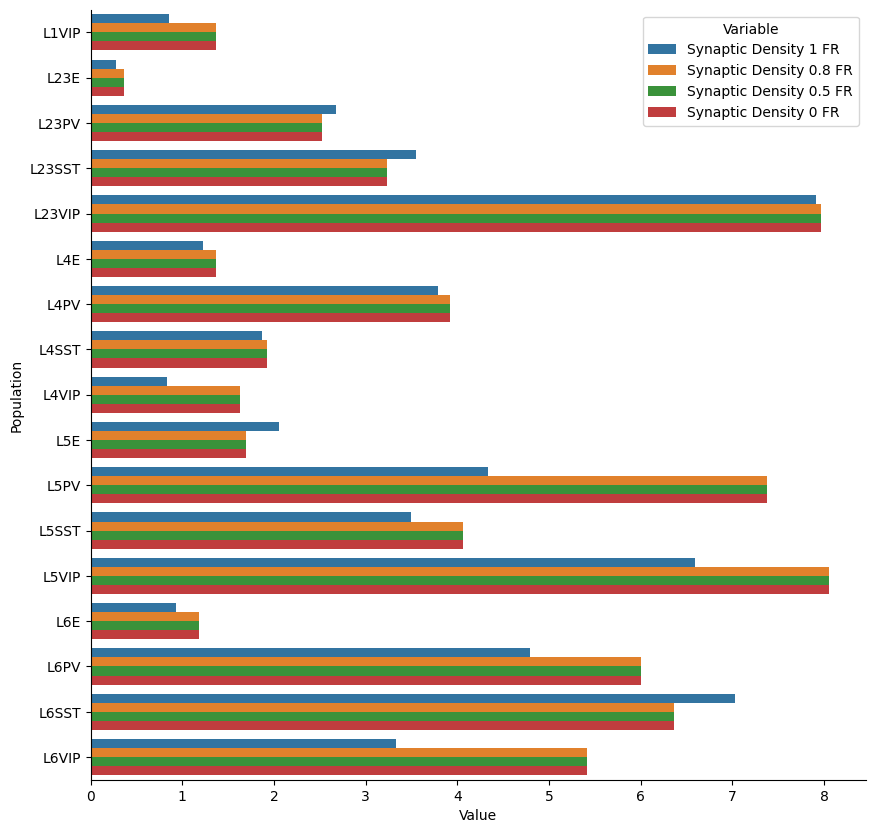

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 10))
tidy = combined_data.melt(id_vars='Population').rename(columns=str.title)
sns.barplot(x='Value', y='Population', hue='Variable', data=tidy, ax=ax1)
sns.despine(fig)